# afmkit quickstart — single-molecule force spectroscopy

This notebook takes you from a raw force–extension curve to a
fitted worm-like chain (WLC) model and a publication-ready plot,
using only the public afmkit API.

**What you will see**

1. Build a small `CurveBatch` of synthetic WLC curves (so the
   notebook runs without any external files).
2. Inspect a single `ForceCurve`'s arrays and metadata.
3. Fit the WLC model on a chosen extension sub-range.
4. Export the batch and the fit result to CSV.
5. Plot the data and the fitted curve with matplotlib.

**Prerequisites**

```bash
source .venv/bin/activate
export PYTHONPATH=src      # afmkit's editable install is broken on
                            # Python 3.14 due to a .pth quirk
jupyter nbconvert --to notebook --execute examples/01_quickstart.ipynb --inplace
```


In [1]:
import pathlib; print("CWD:", pathlib.Path.cwd()); print("CWD parent:", pathlib.Path.cwd().parent)

CWD: /Users/malinjie/Documents/MiniMax Project/AFM Data Processing/examples
CWD parent: /Users/malinjie/Documents/MiniMax Project/AFM Data Processing


In [2]:
# Make afmkit importable without an editable install. The project's
# venv's `.pth` registration is broken on Python 3.14, so we add
# src/ to sys.path explicitly. This is a no-op if afmkit is already
# importable (e.g. when the user has run `pip install -e .` on a
# working Python).
import sys
from pathlib import Path

# Walk up from CWD until we find a `src/afmkit/__init__.py`. This is
# robust against running the notebook from `examples/`, from the
# project root, or from a checkout of the repo elsewhere on disk.
_p = Path.cwd().resolve()
_src = None
for _candidate in (_p, *_p.parents):
    _s = _candidate / "src"
    if (_s / "afmkit" / "__init__.py").is_file():
        _src = _s
        break
if _src is not None and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
del _p, _candidate, _s, _src

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from afmkit.core.curve import CurveBatch, ForceCurve
from afmkit.fitting import fit
from afmkit.io.exporters import to_csv, to_csv_fits

print("afmkit loaded from:", __import__("afmkit").__file__)


afmkit loaded from: /Users/malinjie/Documents/MiniMax Project/AFM Data Processing/src/afmkit/__init__.py


In [3]:
# Build a noise-free WLC curve (Marko–Siggia) — the same formula
# used in tests/conftest.py:synthetic_wlc_force, inlined here so
# the notebook has no test-only imports.
#
#   F(x) = (kT / p) * (0.25 / (1 - x/L)^2 - 0.25 + x/L)
#
# with kT = 4.1 pN·nm, p = 0.4 nm, L = 200 nm.

p_nm, Lc_nm = 0.4, 200.0
kT = 4.1  # pN·nm

# Avoid the WLC singularity at x = L by stopping the axis at 0.999·L.
x_clean = np.linspace(0.5, 0.999 * Lc_nm, 1000)
y_clean = (kT / p_nm) * (
    0.25 * (1.0 - x_clean / Lc_nm) ** -2 - 0.25 + x_clean / Lc_nm
)

curve = ForceCurve(
    extension=x_clean,
    force=y_clean,
    metadata={
        "k_cantilever": 0.10,        # pN/nm
        "temperature": 298.0,        # K
        "source_file": "synthetic",
        "direction": "retract",
    },
)
batch = CurveBatch([curve], name="quickstart")
print(curve)
print(batch)


ForceCurve(n_points=1000, ext=[0.5, 199.8] nm, F=[0.0, 2562507.7] pN, k=0.1)
CurveBatch('quickstart' n_curves=1)


In [4]:
# Inspect the curve's contents. The arrays are numpy float64 views;
# the metadata dict is the per-curve attrs bag.

print("extension[:5] =", curve.extension[:5])
print("force[:5]     =", curve.force[:5])
print("metadata      =", curve.metadata)
print("batch.n_curves=", batch.n_curves)


extension[:5] = [0.5       0.6994995 0.898999  1.0984985 1.297998 ]
force[:5]     = [0.03848571 0.0538685  0.06926681 0.08468069 0.10011022]
metadata      = {'k_cantilever': 0.1, 'temperature': 298.0, 'source_file': 'synthetic', 'direction': 'retract'}
batch.n_curves= 1


In [5]:
# Fit the WLC model on the 20–180 nm window — that range stays well
# clear of the singularity at x = L and the low-force baseline at
# x ≈ 0. The fit never raises on a non-converging result; it
# returns a FitResult with metadata['success'] = False instead.

result = fit(curve, model="wlc", x_range=(20.0, 180.0))
print(result.summary())
print()
print("params =", result.params)


FitResult[WLCModel]
-------------------
  status            : ok
  n_data            : 802
  n_params (vary)   : 2
  chi_square        : 1.44534e-22
  reduced_chi_square: 1.80667e-25
  AIC               : -45690.5
  BIC               : -45681.1
  R^2               : 1
  parameters:
    p = 0.4  +/- 3.541e-16
    L = 200  +/- 1.374e-14
  metadata:
    method: 'leastsq'
    nfev: 16
    nfree: 800
    fit_range: [20.0, 180.0]
    initial_params: {'p': 0.4, 'L': 197.8350550550551}

params = {'p': 0.40000000000000224, 'L': 199.9999999999998}


In [6]:
# Export the batch (wide column-block CSV: ext_NNN / force_NNN pairs)
# and the fit result (one-row-per-fit CSV) so analysts can hand the
# files off to Origin / Excel / Matlab without any post-processing.

batch_csv = "/tmp/quickstart.csv"
fit_csv = "/tmp/quickstart_fits.csv"
to_csv(batch, batch_csv)
to_csv_fits([result], fit_csv)
print(f"wrote {batch_csv} and {fit_csv}")
print()
print("first 3 lines of the batch CSV:")


wrote /tmp/quickstart.csv and /tmp/quickstart_fits.csv

first 3 lines of the batch CSV:


In [7]:
!head -3 /tmp/quickstart.csv

ext_000,force_000,source_file_000,direction_000,k_cantilever_000
0.5,0.038485707533244,synthetic,retract,0.1
0.6994994994994995,0.053868501733275925,synthetic,retract,0.1


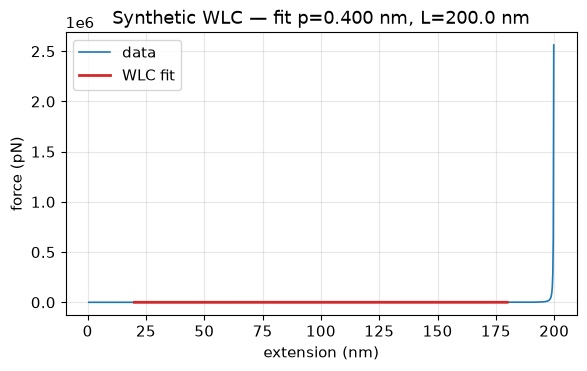

In [8]:
# Plot the data and the fitted WLC. matplotlib only — no plotly,
# no seaborn, no plugin dependency. The fit's y_fit is the model
# evaluated on the data points that survived the x_range filter,
# so we overlay it on a matching index of the original axis.

matplotlib.rcParams.update({
    "figure.figsize": (6.0, 4.0),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

fig, ax = plt.subplots()
ax.plot(curve.extension, curve.force, color="#1f77b4", lw=1.2, label="data")
ax.plot(result.x_fit, result.y_fit, color="#d62728", lw=2.0, label="WLC fit")
ax.set_xlabel("extension (nm)")
ax.set_ylabel("force (pN)")
p_est, L_est = result.params["p"], result.params["L"]
ax.set_title(f"Synthetic WLC — fit p={p_est:.3f} nm, L={L_est:.1f} nm")
ax.legend()
fig.tight_layout()
plt.show()


**Next steps**

- `examples/02_batch_processing.ipynb` (v0.2) — full folder ingest
  and batch peak finding for a real ~100-curve lab folder.
- Replace the synthetic curve with a real load:
  `from afmkit.io import JPKTxtLoader; loader = JPKTxtLoader();
  batch = loader.load(pathlib.Path("data/curve001.txt"), k_cantilever=0.06)`.
- Re-fit with a different model: `fit(curve, model="fjc")` once the
  FJC plugin is installed (v0.2+).
